In [1]:
import pandas as pd

ptb_xl_df = pd.read_csv("../results/ptb_xl.csv", index_col=0).reset_index(drop=True)
cpsc2018_df = pd.read_csv("../results/cpsc2018.csv", index_col=0).reset_index(drop=True)
mit_cls_df = pd.read_csv("../results/mit_cls.csv", index_col=0).reset_index(drop=True)
sleep_apnea_df = pd.read_csv("../results/sleep_apnea.csv", index_col=0).reset_index(drop=True)
ppg_df = pd.read_csv("../results/ppg.csv", index_col=0).reset_index(drop=True)
exercise_df = pd.read_csv("../results/exercise.csv", index_col=0).reset_index(drop=True)
mit_rpeaks_df = pd.read_csv("../results/mit_rpeaks.csv", index_col=0).reset_index(drop=True)
age_df = pd.read_csv("../results/age.csv", index_col=0).reset_index(drop=True)
lab_mimic_df = pd.read_csv("../results/lab_mimic.csv", index_col=0).reset_index(drop=True)
survival_df = pd.read_csv("../results/survival.csv", index_col=0).reset_index(drop=True)

In [2]:
def preprocess_age(df):
    # convert to float
    df['mean_r2'] = (df['ptbxl/test_r2/dataloader_idx_0'] + df['mimic/test_r2/dataloader_idx_1'] + df['cpsc/test_r2/dataloader_idx_2']) / 3
    return df

data = {
    'PTB-XL / AUC': ('test_auroc', ptb_xl_df, None),
    'CPSC2018 / AUC': ('test_auroc', cpsc2018_df, None),
    'MIT-BIH / F1': ('test_f1/mean', mit_cls_df, None),
    'Sleep Apnea / AUC': ('test_auc', sleep_apnea_df, None),
    'Exercise R-Peak / F1': ('test_f1_20', exercise_df, None),
    'R-Peaks / F1': ('test_f1_20', mit_rpeaks_df, None),
    'Age / R^2': ('mean_r2', age_df, preprocess_age),
    'LAB test / AUC': ('test_auroc_avg', lab_mimic_df, None),
    'Mortality / CI': ('test_ci', survival_df, None),
    'PPG / AUC': ('test_auroc', ppg_df, None)
}

In [3]:
# add to all dataframes the reference metric
for key, (metric, df, preprocess) in data.items():
    if preprocess:
        df = preprocess(df)
    df['reference'] = df[metric]

In [4]:
methods_main = ['xECG', 'ECG-CPC', 'ST-MEM', 'ECG-JEPA', 'ECG Founder']
groups_main_lp = ['best_xlstm_lp', 'best_ecgcpc_lp', 'best_stmem_lp', 'best_jepa_lp', 'best_ecgfm_lp' ]
groups_main_ft = ['best_xlstm_ft','best_ecgcpc_ft', 'best_stmem_ft', 'best_jepa_ft', 'best_ecgfm_ft' ]

methods_ablations = ['xECG', 'xECG (signal view)', 'xECG (reduced pretraining)', 'SimDINOv2 Transformer', 'Supervised xLSTM']
groups_abl_lp = ['best_xlstm_lp',  'best_dinoecg_xlstm_lp', 'best_code15_xlstm_lp', 'best_trans_lp']
groups_abl_ft = ['best_xlstm_ft', 'best_dinoecg_xlstm_ft', 'best_code15_xlstm_ft', 'best_trans_ft',  'best_xlstm_sup']


In [5]:
import numpy as np
import pandas as pd
from scipy import stats

def _precompute_group_values(data):
    """
    One groupby per dataframe instead of one boolean mask per (group, method)
    call. Returns {key: {group: np.ndarray of 'reference' values}}.
    """
    group_values = {}
    for key, (metric, df, _) in data.items():
        group_values[key] = {
            g: s.to_numpy() for g, s in df.groupby('group')['reference']
        }
    return group_values


def get_full_results(data, groups, methods, random=False, group_values=None):
    """
    Same output as the original: index = methods, columns = ['bench_score', 'avg_rank'].
    Uses precomputed group arrays instead of re-filtering the dataframe each call.
    """
    if group_values is None:
        group_values = _precompute_group_values(data)

    keys = list(data.keys())
    values = np.empty((len(methods), len(keys)))

    for j, key in enumerate(keys):
        gv = group_values[key]
        for i, group in enumerate(groups):
            arr = gv[group]
            values[i, j] = arr[np.random.randint(len(arr))] if random else arr.mean()

    df = pd.DataFrame(values, index=methods, columns=keys)
    df2 = pd.DataFrame(index=methods)
    df2['bench_score'] = df.mean(axis=1)
    df2['avg_rank'] = df.rank(ascending=False).mean(axis=1)
    return df2


def _summarize(arr):
    # arr: (num_iterations, ...) -> mean/std/ci95 along axis 0, fully vectorized
    n = arr.shape[0]
    mean = arr.mean(axis=0)
    std = arr.std(axis=0, ddof=1)
    sem = std / np.sqrt(n)
    t_val = stats.t.ppf(0.975, n - 1)
    return mean, std, mean - t_val * sem, mean + t_val * sem


def _pairwise_bench_score_diffs(bench_score, methods):
    """
    bench_score: (num_iterations, n_methods) bootstrap draws.
    For every pair (a, b) with a before b in `methods`, computes the
    bootstrap distribution of (score_a - score_b) via broadcasting
    (no extra sampling -- reuses the same bootstrap draws), then summarizes
    it into mean/std/95% CI, plus P(a > b) as a bonus significance signal.
    """
    n_iter, n_methods = bench_score.shape
    # diffs[:, i, j] = bench_score[:, i] - bench_score[:, j] for every iteration at once
    diffs = bench_score[:, :, None] - bench_score[:, None, :]  # (n_iter, n_methods, n_methods)

    mean, std, lo, hi = _summarize(diffs)  # each (n_methods, n_methods)
    prob_a_gt_b = (diffs > 0).mean(axis=0)  # (n_methods, n_methods)

    rows = []
    for i in range(n_methods):
        for j in range(i + 1, n_methods):
            rows.append({
                'method_a': methods[i],
                'method_b': methods[j],
                'mean_diff': mean[i, j],
                'std_diff': std[i, j],
                'ci95_low': lo[i, j],
                'ci95_high': hi[i, j],
                'prob_a_gt_b': prob_a_gt_b[i, j],
            })
    return pd.DataFrame(rows).set_index(['method_a', 'method_b'])


def get_full_results_bootstrapped(data, groups, methods, num_iterations=10000, seed=None):
    """
    Fully vectorized bootstrap:
      - draws all `num_iterations` random samples per (key, group) in one shot
        via integer indexing instead of calling get_full_results in a Python loop
      - computes bench_score / avg_rank for every iteration with array ops
      - computes mean/std/95% CI across iterations with numpy + vectorized
        scipy.stats.t.ppf, instead of groupby(...).agg([...]) over 10000 concatenated dfs
      - computes bootstrapped pairwise bench_score differences (and their 95% CI)
        between every pair of methods, reusing the same bootstrap draws

    Returns:
      df_out   : DataFrame indexed by `methods`, MultiIndex columns
                 (bench_score/avg_rank) x (mean/std/ci95_low/ci95_high)
      pairwise : DataFrame indexed by (method_a, method_b), columns
                 mean_diff/std_diff/ci95_low/ci95_high/prob_a_gt_b,
                 where mean_diff = bench_score[method_a] - bench_score[method_b]
    """
    rng = np.random.default_rng(seed)
    group_values = _precompute_group_values(data)

    keys = list(data.keys())
    n_keys, n_methods = len(keys), len(methods)

    # samples[iteration, method, key]
    samples = np.empty((num_iterations, n_methods, n_keys))
    for j, key in enumerate(keys):
        gv = group_values[key]
        for i, group in enumerate(groups):
            arr = gv[group]
            idx = rng.integers(0, len(arr), size=num_iterations)  # vectorized "sample(n=1)"
            samples[:, i, j] = arr[idx]

    # bench_score: mean over keys, per (iteration, method)
    bench_score = samples.mean(axis=2)  # (num_iterations, n_methods)

    # avg_rank: rank methods within each key (descending), then mean over keys
    # rankdata(axis=1) ranks along the "method" axis for every (iteration, key) slice
    ranks = stats.rankdata(-samples, axis=1, method='average')  # descending == rank of negated values
    avg_rank = ranks.mean(axis=2)  # (num_iterations, n_methods)

    bs_mean, bs_std, bs_lo, bs_hi = _summarize(bench_score)
    ar_mean, ar_std, ar_lo, ar_hi = _summarize(avg_rank)

    df_out = pd.DataFrame(
        {
            ('bench_score', 'mean'): bs_mean,
            ('bench_score', 'std'): bs_std,
            ('bench_score', 'ci95_low'): bs_lo,
            ('bench_score', 'ci95_high'): bs_hi,
            ('avg_rank', 'mean'): ar_mean,
            ('avg_rank', 'std'): ar_std,
            ('avg_rank', 'ci95_low'): ar_lo,
            ('avg_rank', 'ci95_high'): ar_hi,
        },
        index=methods,
    )
    df_out.columns = pd.MultiIndex.from_tuples(df_out.columns)

    pairwise = _pairwise_bench_score_diffs(bench_score, methods)

    return df_out, pairwise

In [6]:
main_ft, pairwise_main_ft = get_full_results_bootstrapped(data, groups_main_ft, methods_main)
main_lp, pairwise_main_lp = get_full_results_bootstrapped(data, groups_main_lp, methods_main)
main_abl_ft, pairwise_main_abl_ft = get_full_results_bootstrapped(data, groups_abl_ft, methods_ablations)
main_abl_lp, pairwise_main_abl_lp = get_full_results_bootstrapped(data, groups_abl_lp, methods_ablations) 

main_all_ft, pairwise_main_all_ft = get_full_results_bootstrapped(data, groups_main_ft + groups_abl_ft, methods_main + methods_ablations)

In [7]:
colors = {
    "ST-MEM": "#636EFA",
    "ECG-JEPA": "#EF553B",
    "ECG Founder": "#00CC96",
    "ECG-CPC": "#FFB6C1",
    "xECG": "#FFA15A",
    # "SimDINOv2 Transformer": "#8F7AE5",
    # "Supervised xLSTM": "#4FB6C2",
    # "xECG (signal view)": "#E89B3F",
    # "xECG (reduced pretraining)": "#5FBF8F"
}

pastel_colors = [f"{color}C0" for color in colors.values()]  

# assign pastel colors to the dataframes matching the keys of the colors dict
main_lp['pastel_color'] = [colors[method] for method in main_lp.index]
main_ft['pastel_color'] = [colors[method] for method in main_ft.index]

In [8]:
main_ft["avg_rank_mean"] = main_ft["avg_rank"]["mean"]
main_lp["avg_rank_mean"] = main_lp["avg_rank"]["mean"]

main_abl_ft["avg_rank_mean"] = main_abl_ft["avg_rank"]["mean"]
main_abl_lp["avg_rank_mean"] = main_abl_lp["avg_rank"]["mean"]

/tmp/ipykernel_2611129/352898296.py:4: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df_ranked_sorted = df.copy().drop(columns=["pastel_color"])
/tmp/ipykernel_2611129/352898296.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(df_ranked_sorted.index, fontsize=24)
/tmp/ipykernel_2611129/352898296.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)
/tmp/ipykernel_2611129/352898296.py:4: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df_ranked_sorted = df.copy().drop(columns=["pastel_color"])
/tmp/ipykernel_2611129/352898296.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. aft

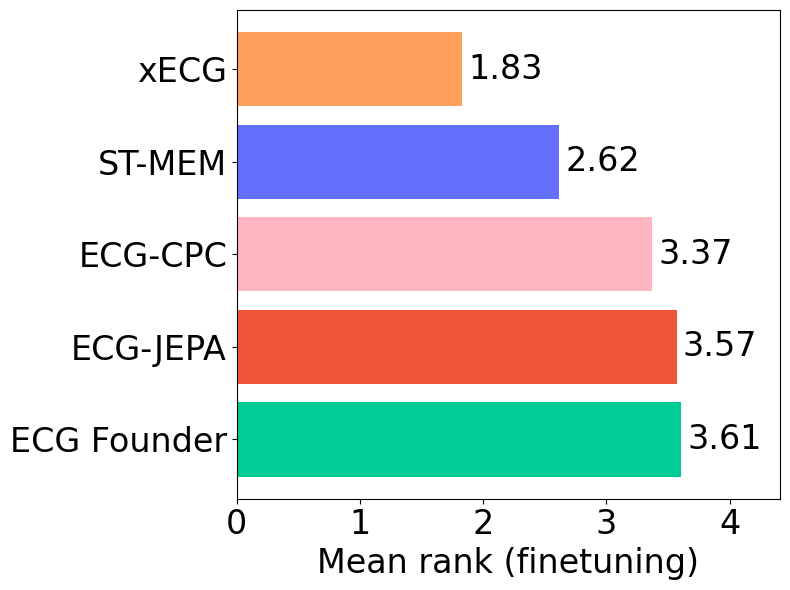

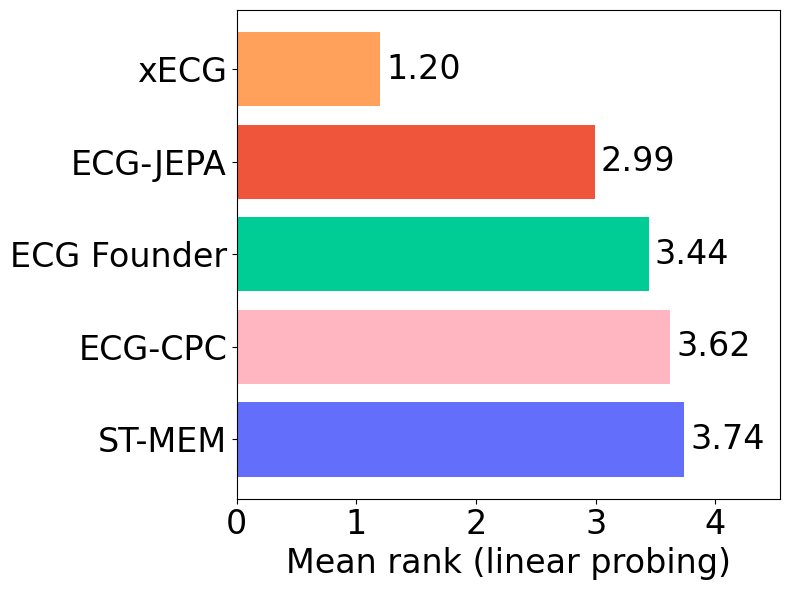

In [9]:
import matplotlib.pyplot as plt

def plot_bench_rank(df, name='mean_rank_methods.png', title=''):
    df_ranked_sorted = df.copy().drop(columns=["pastel_color"])
    df_ranked_sorted = df_ranked_sorted.sort_values(by="avg_rank_mean", ascending=True)

    df_ranked_sorted["pastel_color"] = df["pastel_color"]

    fig, ax = plt.subplots(figsize=(8, 6))

    # Draw horizontal bars
    bars = ax.barh(df_ranked_sorted.index, df_ranked_sorted["avg_rank_mean"], color=df_ranked_sorted["pastel_color"])
    ax.set_yticklabels(df_ranked_sorted.index, fontsize=24)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=24)

    # Add labels to bars
    for i, (value, label) in enumerate(zip(df_ranked_sorted["avg_rank_mean"], df_ranked_sorted.index)):
        ax.text(value + 0.05, i, f"{value:.2f}", va='center', ha='left', fontsize=24, color='black')
    
    ax.set_xticks([0, 1, 2, 3, 4, 5])                  # positions of the ticks
    ax.set_xticklabels([0, 1, 2, 3, 4, 5], fontsize=24)

    # Format plo
    ax.set_xlabel(title, fontsize=24)
    #ax.set_ylabel('Method', fontsize=12)
    # ax.set_title('Mean Rank of Methods', fontsize=14, weight='bold', pad=15)
    ax.invert_yaxis()  # Highest rank at top
    ax.set_xlim([0, df_ranked_sorted["avg_rank_mean"].max() + 0.8])  # Adjust x-axis limit

    plt.tight_layout()
    plt.savefig(name, dpi=300)

plot_bench_rank(main_ft, "../figs/mean_rank_methods_bootstrapped.svg", title='Mean rank (finetuning)')
plot_bench_rank(main_lp, "../figs/mean_rank_methods_lp_bootstrapped.svg", title='Mean rank (linear probing)')

In [10]:
pairwise_main_all_ft

mean_diff  std_diff  \
method_a                   method_b                                          
xECG                       ECG-CPC                      0.040745  0.004539   
                           ST-MEM                       0.045411  0.005998   
                           ECG-JEPA                     0.054925  0.004776   
                           ECG Founder                  0.249922  0.007247   
                           xECG                         0.000052  0.004139   
                           xECG (signal view)           0.017887  0.005446   
                           xECG (reduced pretraining)   0.036370  0.003559   
                           SimDINOv2 Transformer        0.112402  0.005533   
                           Supervised xLSTM             0.069016  0.004120   
ECG-CPC                    ST-MEM                       0.004666  0.006228   
                           ECG-JEPA                     0.014180  0.005076   
                           ECG Founder                  0.209177  0.007517   
                           xECG                        -0.040693  0.004591   
                           xECG (signal view)          -0.022858  0.005736   
                           xECG (reduced pretraining)  -0.004375  0.003992   
                           SimDINOv2 Transformer        0.071657  0.005843   
                           Supervised xLSTM             0.028271  0.004472   
ST-MEM                     ECG-JEPA                     0.009514  0.006465   
                           ECG Founder                  0.204511  0.008375   
                           xECG                        -0.045359  0.006032   
                           xECG (signal view)          -0.027524  0.006971   
                           xECG (reduced pretraining)  -0.009041  0.005635   
                           SimDINOv2 Transformer        0.066992  0.006956   
                           Supervised xLSTM             0.023606  0.005994   
ECG-JEPA                   ECG Founder                  0.194997  0.007561   
                           xECG                        -0.054873  0.004797   
                           xECG (signal view)          -0.037038  0.005949   
                           xECG (reduced pretraining)  -0.018555  0.004260   
                           SimDINOv2 Transformer        0.057478  0.006002   
                           Supervised xLSTM             0.014092  0.004739   
ECG Founder                xECG                        -0.249870  0.007258   
                           xECG (signal view)          -0.232035  0.007994   
                           xECG (reduced pretraining)  -0.213552  0.006919   
                           SimDINOv2 Transformer       -0.137520  0.008151   
                           Supervised xLSTM            -0.180906  0.007190   
xECG                       xECG (signal view)           0.017835  0.005455   
                           xECG (reduced pretraining)   0.036318  0.003593   
                           SimDINOv2 Transformer        0.112351  0.005536   
                           Supervised xLSTM             0.068965  0.004103   
xECG (signal view)         xECG (reduced pretraining)   0.018483  0.005029   
                           SimDINOv2 Transformer        0.094516  0.006621   
                           Supervised xLSTM             0.051130  0.005433   
xECG (reduced pretraining) SimDINOv2 Transformer        0.076032  0.005075   
                           Supervised xLSTM             0.032646  0.003508   
SimDINOv2 Transformer      Supervised xLSTM            -0.043386  0.005476   

                                                       ci95_low  ci95_high  \
method_a                   method_b                                          
xECG                       ECG-CPC                     0.040656   0.040834   
                           ST-MEM                      0.045293   0.045528   
                           ECG-JEPA                    0.054831   0.055018  

In [11]:
main_all_ft

bench_score                                \
                                  mean       std  ci95_low ci95_high   
xECG                          0.838043  0.002930  0.837986  0.838101   
ECG-CPC                       0.797298  0.003469  0.797230  0.797366   
ST-MEM                        0.792632  0.005228  0.792530  0.792735   
ECG-JEPA                      0.783118  0.003759  0.783045  0.783192   
ECG Founder                   0.588121  0.006614  0.587991  0.588251   
xECG                          0.837991  0.002978  0.837933  0.838050   
xECG (signal view)            0.820157  0.004615  0.820066  0.820247   
xECG (reduced pretraining)    0.801673  0.002028  0.801633  0.801713   
SimDINOv2 Transformer         0.725641  0.004676  0.725549  0.725732   
Supervised xLSTM              0.769027  0.002866  0.768971  0.769083   

                            avg_rank                                
                                mean       std  ci95_low ci95_high  
xECG                        2.750505  0.283246  2.744953  2.756057  
ECG-CPC                     5.910840  0.290277  5.905150  5.916530  
ST-MEM                      4.537640  0.171599  4.534276  4.541004  
ECG-JEPA                    6.398220  0.225841  6.393793  6.402647  
ECG Founder                 7.130430  0.200392  7.126502  7.134358  
xECG                        2.752635  0.286055  2.747028  2.758242  
xECG (signal view)          4.017080  0.317903  4.010848  4.023312  
xECG (reduced pretraining)  5.952980  0.214834  5.948769  5.957191  
SimDINOv2 Transformer       7.684880  0.179211  7.681367  7.688393  
Supervised xLSTM            7.864790  0.181963  7.861223  7.868357

In [12]:
def format_summary_stats(df_out, metric='bench_score', methods=None, decimals=4):
    """
    Build formatted strings 'mean ± std [ci_low, ci_high]' from df_out.
 
    Parameters
    ----------
    df_out : pd.DataFrame
        Output of get_full_results_bootstrapped (MultiIndex columns:
        (metric, stat) with stat in {'mean','std','ci95_low','ci95_high'}).
    metric : str
        Which metric column to format (e.g. 'bench_score', 'avg_rank').
    methods : list or None
        Subset/order of methods (index) to include. Defaults to df_out.index.
    decimals : int
        Number of decimal places.
 
    Returns
    -------
    pd.Series indexed by method, values are formatted strings.
    """
    if methods is None:
        methods = list(df_out.index)
 
    fmt = f"{{:.{decimals}f}}"
    # single slice instead of 4 * n_methods individual .loc[m, (metric, stat)] lookups
    sub = df_out.loc[methods, metric]
    mean, std, lo, hi = (sub[c].to_numpy() for c in ('mean', 'std', 'ci95_low', 'ci95_high'))
 
    formatted = [
        f"{fmt.format(m)} \u00b1 {fmt.format(s)} [{fmt.format(l)}, {fmt.format(h)}]"
        for m, s, l, h in zip(mean, std, lo, hi)
    ]
    return pd.Series(formatted, index=methods, name=metric)
 
print(format_summary_stats(main_ft, metric='bench_score'))

xECG           0.8380 ± 0.0030 [0.8379, 0.8380]
ECG-CPC        0.7973 ± 0.0035 [0.7972, 0.7973]
ST-MEM         0.7926 ± 0.0052 [0.7925, 0.7927]
ECG-JEPA       0.7831 ± 0.0038 [0.7830, 0.7832]
ECG Founder    0.5884 ± 0.0066 [0.5882, 0.5885]
Name: bench_score, dtype: str


In [13]:
print(format_summary_stats(main_abl_ft, metric='bench_score'))

xECG                          0.8380 ± 0.0030 [0.8380, 0.8381]
xECG (signal view)            0.8201 ± 0.0046 [0.8200, 0.8202]
xECG (reduced pretraining)    0.8016 ± 0.0020 [0.8016, 0.8017]
SimDINOv2 Transformer         0.7257 ± 0.0047 [0.7256, 0.7258]
Supervised xLSTM              0.7690 ± 0.0028 [0.7690, 0.7691]
Name: bench_score, dtype: str


In [14]:
print(format_summary_stats(main_lp, metric='bench_score'))

xECG           0.7714 ± 0.0026 [0.7714, 0.7715]
ECG-CPC        0.6553 ± 0.0069 [0.6551, 0.6554]
ST-MEM         0.6489 ± 0.0043 [0.6489, 0.6490]
ECG-JEPA       0.6470 ± 0.0047 [0.6469, 0.6471]
ECG Founder    0.5505 ± 0.0066 [0.5504, 0.5506]
Name: bench_score, dtype: str


In [15]:
print(format_summary_stats(main_abl_lp, metric='bench_score'))

xECG                          0.7714 ± 0.0026 [0.7714, 0.7715]
xECG (signal view)            0.7612 ± 0.0033 [0.7611, 0.7612]
xECG (reduced pretraining)    0.7463 ± 0.0036 [0.7462, 0.7463]
SimDINOv2 Transformer         0.6342 ± 0.0040 [0.6341, 0.6343]
Supervised xLSTM              0.7690 ± 0.0028 [0.7690, 0.7691]
Name: bench_score, dtype: str
